## Step 1

Hospital readmissions within 30 days after discharge are a critical concern for healthcare systems, as they increase costs, decrease the quality of care, and contribute to overcrowded hospitals. Predicting patients at high risk of readmission allows hospitals to intervene proactively and implement preventive measures, which in turn can improve patient outcomes and reduce unnecessary costs.

Data Science Problem Framing:
The task at hand is a classification problem, where the goal is to predict whether a patient will be readmitted within 30 days after discharge based on various factors such as patient demographics, medical history, and treatment data. This problem can be approached as a binary classification, where the target variable is:
1 if the patient is readmitted within 30 days
0 if the patient is not readmitted

Success Metrics:
Accuracy: Percentage of correct predictions (both true positives and true negatives).
AUC (Area Under the ROC Curve): Measures the ability of the model to distinguish between the classes.
Precision and Recall: Balances the trade-off between false positives and false negatives, especially important in healthcare contexts.
F1-Score: A harmonic mean of Precision and Recall to provide a balanced measure.
Cost Savings: The reduction in costs due to fewer readmissions, which could be tied to preventive interventions and better resource management.
Business KPIs:
Cost Savings: A reduction in the costs associated with unnecessary hospital readmissions.
Uplift in Patient Outcomes: The improvement in patient health outcomes through targeted interventions and preventive care.
Operational Efficiency: The ability of the hospital to better allocate resources based on predictions, improving overall healthcare delivery.
Capstone Linkage:
The outputs from this step will guide the subsequent steps (Capstone Steps 1–3), where the data will be explored, preprocessed, and modeled to build a predictive framework for readmissions.

In [38]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import scipy.stats as stats
from scipy.stats import f_oneway
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN

import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from xgboost import XGBClassifier
from keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    silhouette_score
)
from sklearn.model_selection import RandomizedSearchCV

In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Step 2

In [3]:
# Import Data From Kaggle
# https://www.kaggle.com/datasets/algozee/hospital-readmission-risk-prediction-2026?resource=download
df = pd.read_csv('hospital_readmission_risk_dataset_2026_v1_18000rows.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             18000 non-null  int64  
 1   Gender                          18000 non-null  str    
 2   Insurance_Type                  18000 non-null  str    
 3   Socioeconomic_Risk_Score        18000 non-null  int64  
 4   Previous_Admissions_6M          18000 non-null  int64  
 5   Previous_Readmissions_1Y        18000 non-null  int64  
 6   Time_Since_Last_Discharge       18000 non-null  int64  
 7   Length_of_Stay                  18000 non-null  int64  
 8   Admission_Type                  18000 non-null  str    
 9   Primary_Diagnosis_Group         18000 non-null  str    
 10  Comorbidity_Index               18000 non-null  int64  
 11  Chronic_Disease_Count           18000 non-null  int64  
 12  ICU_Stay_Flag                   18000 non-n

In [4]:
df

,Age,Gender,Insurance_Type,Socioeconomic_Risk_Score,Previous_Admissions_6M,Previous_Readmissions_1Y,Time_Since_Last_Discharge,Length_of_Stay,Admission_Type,Primary_Diagnosis_Group,...,Creatinine_Level,Hemoglobin_Level,Average_Systolic_BP,Number_of_Medications,Medication_Change_Count,High_Risk_Medication_Flag,Followup_Appointment_Scheduled,Discharge_Disposition,Medication_Adherence_Score,Readmitted_Within_30_Days
0,71,Male,Medicare,9,2,0,96,15,Urgent,Infection,...,1.18,10.07,104,5,4,0,0,Rehab,0.54,1
1,34,Female,Private,8,4,0,58,12,Urgent,Infection,...,1.01,13.81,179,6,4,1,1,Rehab,0.42,1
2,80,Male,Medicare,2,1,3,25,11,Urgent,Respiratory,...,1.26,13.25,140,11,4,0,1,Home,0.97,1
3,40,Female,Private,7,2,0,42,2,Elective,Cardiac,...,0.57,15.46,131,9,3,0,1,Rehab,0.95,1
4,43,Male,Medicaid,5,2,1,176,3,Elective,Infection,...,1.05,8.33,171,6,3,0,1,Nursing Facility,0.64,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17995,71,Male,Medicaid,4,1,2,142,13,Elective,Other,...,1.27,16.75,107,4,1,0,1,Home,0.60,1
17996,52,Female,Medicare,6,0,1,4,9,Elective,Cardiac,...,1.92,9.80,126,14,3,0,1,Rehab,0.93,1
17997,70,Male,Medicare,6,1,2,18,15,Elective,Respiratory,...,1.11,13.57,117,12,4,1,1,Home,0.62,1
17998,45,Female,Private,2,2,2,34,13,Emergency,Cardiac,...,0.98,12.56,106,6,1,0,0,Nursing Facility,0.54,1


In [5]:
# Check Missing Values
missing_summary = df.isnull().sum().reset_index()
missing_summary.columns = ['Feature', 'Missing_Count']
missing_summary['Missing_Percent'] = (missing_summary['Missing_Count'] / len(df)) * 100
missing_summary = missing_summary.sort_values(by='Missing_Count', ascending=False)

print("-----------------------------------------------------------------------------")
print("Missing Value Summary:")
print(missing_summary[missing_summary['Missing_Count'] > 0])

-----------------------------------------------------------------------------
Missing Value Summary:
Empty DataFrame
Columns: [Feature, Missing_Count, Missing_Percent]
Index: []


In [6]:
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

# Remove duplicates if any exist
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Duplicate rows removed. New shape: {df.shape}")
else:
    print("No duplicate rows found.")


Number of duplicate rows: 0
No duplicate rows found.


In [7]:
# Check If data is Null, Duplicate, or Has Outliers
def check_outliers_all(df):
    cols_with_outliers = []
    for col in df.select_dtypes(include=['number']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        if len(outliers) > 0:
            cols_with_outliers.append(col)
            print(f"{col}: {len(outliers)} outliers")
    return cols_with_outliers

print("Null")
df.isnull().sum()[df.isnull().sum() > 0]
print("-----------------------------------------------------------------------------")
print("Duplicate")
df.duplicated().any
print("-----------------------------------------------------------------------------")
print("Outliers")
outlier_cols = check_outliers_all(df)

Null
-----------------------------------------------------------------------------
Duplicate
-----------------------------------------------------------------------------
Outliers
Previous_Admissions_6M: 1222 outliers
Previous_Readmissions_1Y: 16 outliers
ICU_Stay_Flag: 3560 outliers
HbA1c_Level: 126 outliers
Creatinine_Level: 130 outliers
Hemoglobin_Level: 155 outliers


## Step 3

In [8]:
# Handle Nulls, Duplicates, and Outliers

# Handle missing values
numerical_columns = [
    'Age', 'Socioeconomic_Risk_Score', 'Previous_Admissions_6M',
    'Previous_Readmissions_1Y', 'Time_Since_Last_Discharge',
    'Length_of_Stay', 'Comorbidity_Index', 'Chronic_Disease_Count',
    'Severity_Score', 'HbA1c_Level', 'Creatinine_Level',
    'Hemoglobin_Level', 'Average_Systolic_BP', 'Number_of_Medications',
    'Medication_Change_Count', 'Medication_Adherence_Score'
]

binary_columns = [
    'ICU_Stay_Flag',
    'High_Risk_Medication_Flag',
    'Followup_Appointment_Scheduled'
]

categorical_columns = [
    'Gender', 'Insurance_Type', 'Admission_Type',
    'Primary_Diagnosis_Group', 'Discharge_Disposition'
]

In [9]:
# Mean imputation for numerical variables
num_imputer = SimpleImputer(strategy='mean')
df[numerical_columns] = num_imputer.fit_transform(df[numerical_columns])

# Mode imputation for binary columns
for col in binary_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Mode imputation for categorical columns
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values after imputation:
Series([], dtype: int64)


In [10]:
# Data Understanding: Distribution Summary
distribution_summary = df[numerical_columns].describe().T
distribution_summary['IQR'] = distribution_summary['75%'] - distribution_summary['25%']

print("\nDistribution Summary for Numerical Features:")
distribution_summary[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'IQR']]


Distribution Summary for Numerical Features:


,mean,std,min,25%,50%,75%,max,IQR
Age,54.504889,20.206770,20.00,37.00,54.00,72.00,89.00,35.00
Socioeconomic_Risk_Score,5.006889,2.582783,1.00,3.00,5.00,7.00,9.00,4.00
Previous_Admissions_6M,1.503944,1.225543,0.00,1.00,1.00,2.00,8.00,1.00
Previous_Readmissions_1Y,0.999667,1.004518,0.00,0.00,1.00,2.00,7.00,2.00
Time_Since_Last_Discharge,90.245889,51.882074,1.00,45.00,91.00,135.00,179.00,90.00
Length_of_Stay,10.049444,5.455903,1.00,5.00,10.00,15.00,19.00,10.00
Comorbidity_Index,2.475556,1.703104,0.00,1.00,2.00,4.00,5.00,3.00
Chronic_Disease_Count,1.991222,1.413951,0.00,1.00,2.00,3.00,4.00,2.00
Severity_Score,5.005500,2.576422,1.00,3.00,5.00,7.00,9.00,4.00
HbA1c_Level,7.001696,1.491568,1.10,5.99,7.02,8.01,12.23,2.02


In [11]:
# Outlier Detection using IQR
def outlier_summary_iqr(dataframe, columns):
    summary = []

    for col in columns:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_mask = (dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)
        outlier_count = outlier_mask.sum()
        outlier_percent = (outlier_count / len(dataframe)) * 100

        summary.append({
            'Feature': col,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound,
            'Outlier_Count': outlier_count,
            'Outlier_Percent': outlier_percent
        })

    return pd.DataFrame(summary).sort_values(by='Outlier_Count', ascending=False)

# outlier_columns = [
#     'Previous_Admissions_6M',
#     'Previous_Readmissions_1Y',
#     'HbA1c_Level',
#     'Creatinine_Level',
#     'Hemoglobin_Level',
#     'Length_of_Stay',
#     'Average_Systolic_BP'
# ]

outlier_report = outlier_summary_iqr(df, outlier_cols)

print("\nOutlier Summary (IQR Method):")
outlier_report


Outlier Summary (IQR Method):


,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percent
2,ICU_Stay_Flag,0.00,0.00,0.00,0.00,0.00,3560,19.777778
0,Previous_Admissions_6M,1.00,2.00,1.00,-0.50,3.50,1222,6.788889
5,Hemoglobin_Level,11.66,14.34,2.68,7.64,18.36,155,0.861111
4,Creatinine_Level,0.93,1.47,0.54,0.12,2.28,130,0.722222
3,HbA1c_Level,5.99,8.01,2.02,2.96,11.04,126,0.700000
1,Previous_Readmissions_1Y,0.00,2.00,2.00,-3.00,5.00,16,0.088889


In [12]:
#  Optional: Remove Outliers
def remove_outliers_iqr(dataframe, columns):
    df_clean = dataframe.copy()

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean = df_clean[
            (df_clean[col] >= lower_bound) &
            (df_clean[col] <= upper_bound)
        ]

    return df_clean

df_clean = remove_outliers_iqr(df, outlier_cols)

print(f"\nOriginal shape: {df.shape}")
print(f"Shape after outlier removal: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")


Original shape: (18000, 25)
Shape after outlier removal: (13151, 25)
Rows removed: 4849


In [13]:
target = 'Readmitted_Within_30_Days'

X = df_clean.drop(columns=[target]).copy()
y = df_clean[target].astype(int).copy()
## #####################################################################################
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numeric columns:
['Age', 'Socioeconomic_Risk_Score', 'Previous_Admissions_6M', 'Previous_Readmissions_1Y', 'Time_Since_Last_Discharge', 'Length_of_Stay', 'Comorbidity_Index', 'Chronic_Disease_Count', 'ICU_Stay_Flag', 'Severity_Score', 'HbA1c_Level', 'Creatinine_Level', 'Hemoglobin_Level', 'Average_Systolic_BP', 'Number_of_Medications', 'Medication_Change_Count', 'High_Risk_Medication_Flag', 'Followup_Appointment_Scheduled', 'Medication_Adherence_Score']

Categorical columns:
['Gender', 'Insurance_Type', 'Admission_Type', 'Primary_Diagnosis_Group', 'Discharge_Disposition']


In [14]:
## #####################################################################################
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
## #####################################################################################
# Imputers
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Impute training data
X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index
)

X_train_cat = pd.DataFrame(
    cat_imputer.fit_transform(X_train[categorical_cols]),
    columns=categorical_cols,
    index=X_train.index
)

# Impute test data using training-fitted imputers
X_test_num = pd.DataFrame(
    num_imputer.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index
)

X_test_cat = pd.DataFrame(
    cat_imputer.transform(X_test[categorical_cols]),
    columns=categorical_cols,
    index=X_test.index
)

In [16]:
# Scale numeric columns using training data only
scaler = StandardScaler()
X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num),
    columns=numeric_cols,
    index=X_train.index
)

X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test_num),
    columns=numeric_cols,
    index=X_test.index
)

In [17]:
# One-hot encode categorical features
X_train_cat_encoded = pd.get_dummies(X_train_cat, drop_first=True)
X_test_cat_encoded = pd.get_dummies(X_test_cat, drop_first=True)

# Align columns to make train/test consistent
X_train_cat_encoded, X_test_cat_encoded = X_train_cat_encoded.align(
    X_test_cat_encoded,
    join='left',
    axis=1,
    fill_value=0
)

In [18]:
# Final processed datasets
X_train_processed = pd.concat([X_train_num_scaled, X_train_cat_encoded], axis=1)
X_test_processed = pd.concat([X_test_num_scaled, X_test_cat_encoded], axis=1)

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (10520, 30)
Testing shape: (2631, 30)


Distributions of Numerical Features


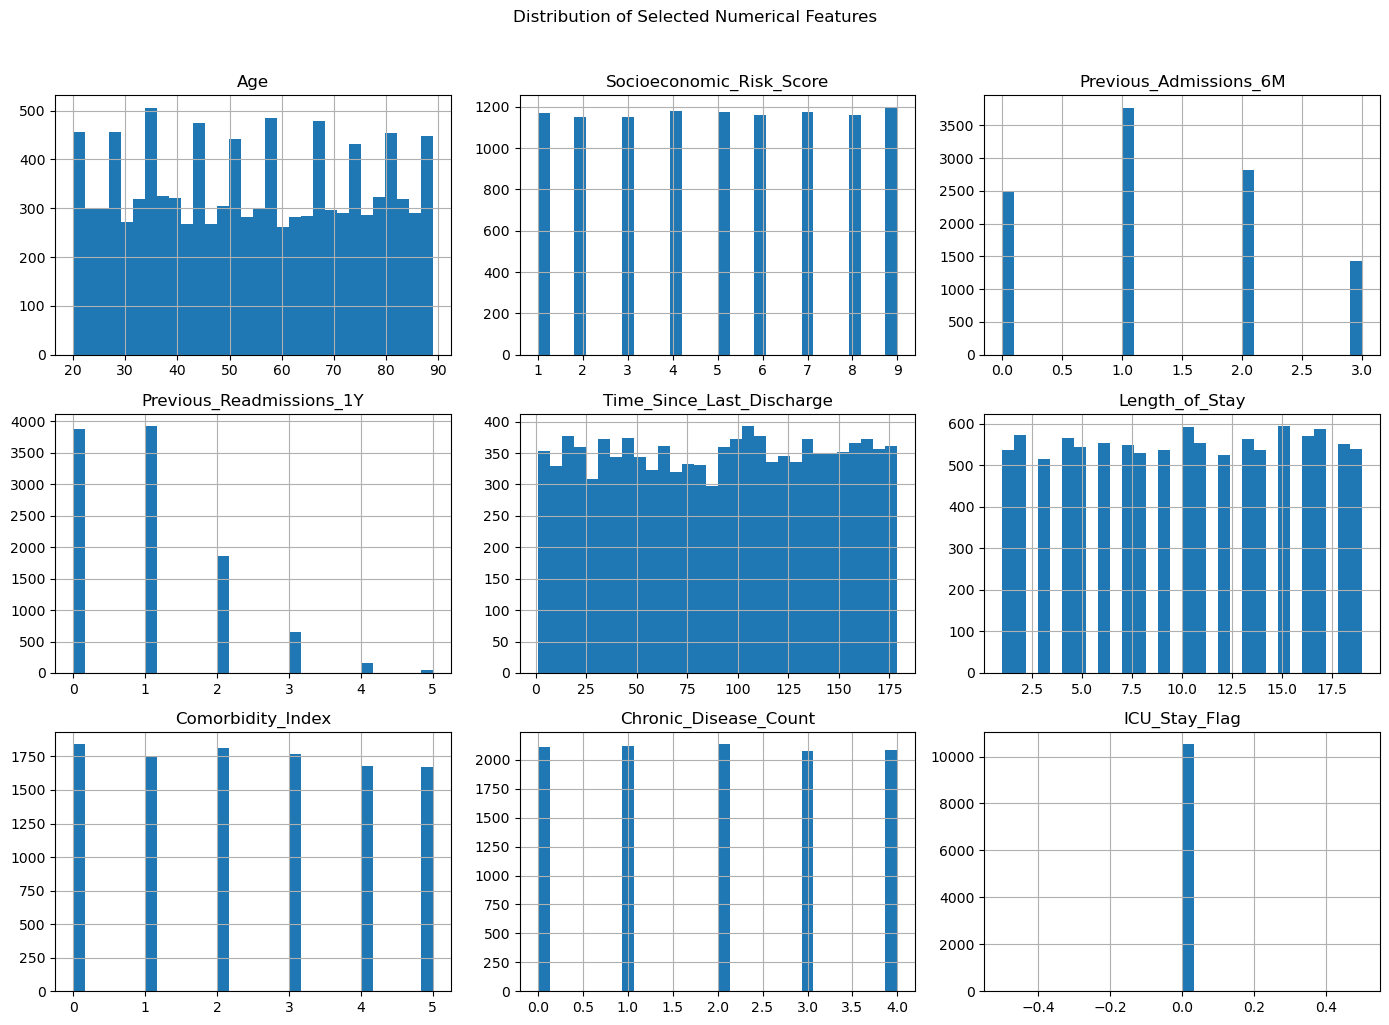

Correlation Heatmap


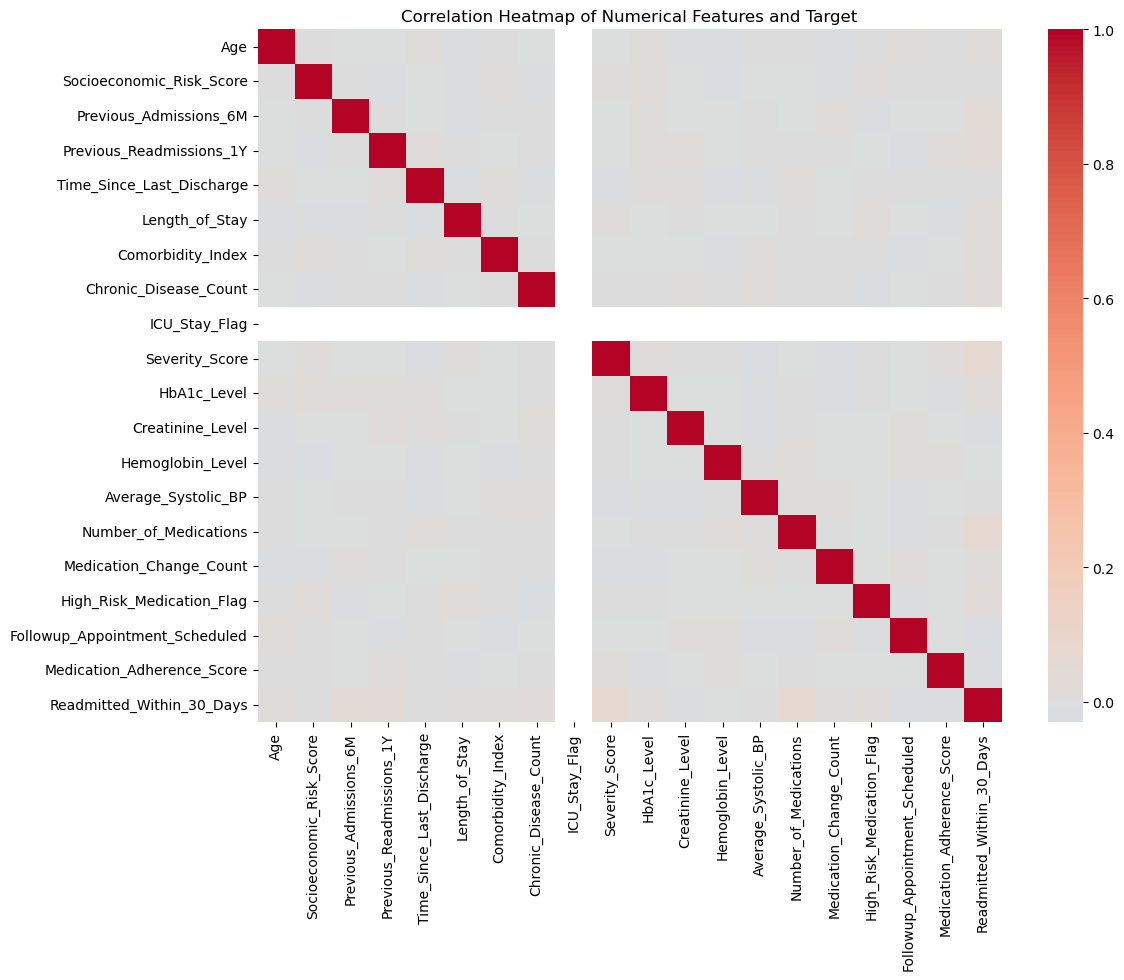

Correlation with Target


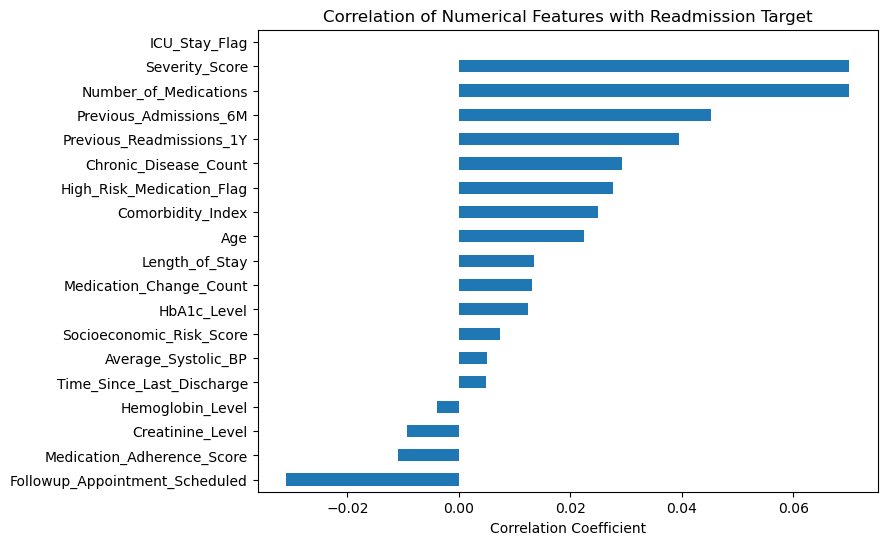

Readmitted_Within_30_Days         1.000000
Severity_Score                    0.070036
Number_of_Medications             0.069896
Previous_Admissions_6M            0.045133
Previous_Readmissions_1Y          0.039517
Chronic_Disease_Count             0.029251
High_Risk_Medication_Flag         0.027650
Comorbidity_Index                 0.024913
Age                               0.022422
Length_of_Stay                    0.013485
Medication_Change_Count           0.013098
HbA1c_Level                       0.012317
Socioeconomic_Risk_Score          0.007299
Average_Systolic_BP               0.005019
Time_Since_Last_Discharge         0.004815
Hemoglobin_Level                 -0.003944
Creatinine_Level                 -0.009352
Medication_Adherence_Score       -0.010851
Followup_Appointment_Scheduled   -0.031067
ICU_Stay_Flag                          NaN
Name: Readmitted_Within_30_Days, dtype: float64
PCA Analysis
Original number of features: 30
Reduced number of PCA components: 17
Explained 

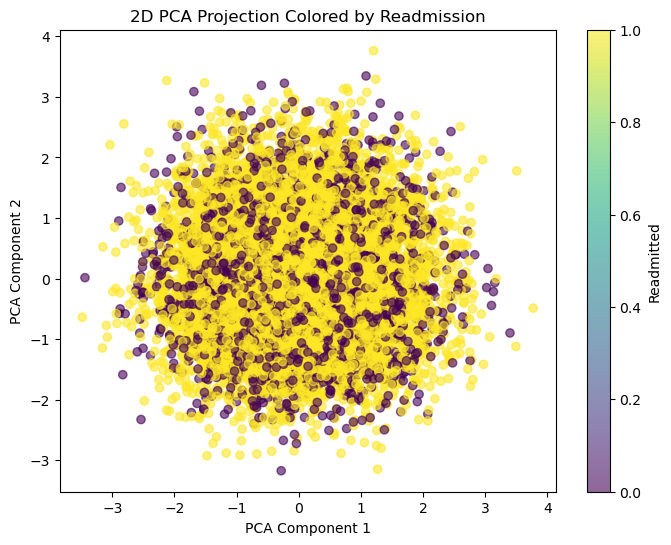

In [19]:
print("Distributions of Numerical Features")

selected_dist_cols = numeric_cols[:9]  # adjust if needed

X_train_num[selected_dist_cols].hist(figsize=(14, 10), bins=30)
plt.suptitle("Distribution of Selected Numerical Features", y=1.02)
plt.tight_layout()
plt.show()
## #####################################################################################
print("Correlation Heatmap")

corr_df = X_train_num.copy()
corr_df[target] = y_train

plt.figure(figsize=(12, 9))
sns.heatmap(corr_df.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Numerical Features and Target")
plt.show()
## ####################################################################################
print("Correlation with Target")

target_corr = corr_df.corr()[target].sort_values(ascending=False)

plt.figure(figsize=(8, 6))
target_corr.drop(target).sort_values().plot(kind='barh')
plt.title("Correlation of Numerical Features with Readmission Target")
plt.xlabel("Correlation Coefficient")
plt.show()

print(target_corr)

## ####################################################################################
print("PCA Analysis")

pca_full = PCA(n_components=0.80, random_state=42)
X_train_pca = pca_full.fit_transform(X_train_processed)

print("Original number of features:", X_train_processed.shape[1])
print("Reduced number of PCA components:", X_train_pca.shape[1])
print("Explained variance ratio sum:", pca_full.explained_variance_ratio_.sum())
## ########################################################################################
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca_2d = pca_2d.fit_transform(X_train_processed)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_train_pca_2d[:, 0],
    X_train_pca_2d[:, 1],
    c=y_train,
    alpha=0.6
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("2D PCA Projection Colored by Readmission")
plt.colorbar(scatter, label="Readmitted")
plt.show()

The provided visuals showcase the following key elements of the dataset, demonstrating a series of analytical techniques to understand the patterns and relationships in the healthcare dataset:
1. Data Distribution:
The first image shows the distribution of various features in the dataset. These include clinical and socio-economic variables, such as:
Age and Socioeconomic Risk Score: Both seem to have balanced distributions with a slight peak in the middle, indicating a normal distribution.
Length of Stay, Comorbidity Index, and other clinical metrics like HbA1c Level and Creatinine Level are also visualized. Most variables show varied distributions with some skewed data (e.g., Severity Score and Medication Change Count).
Readmission Status is heavily imbalanced, with most records indicating no readmission within 30 days, suggesting a need for addressing this imbalance in modeling.
2. Correlation Heatmap:
The second image displays a correlation heatmap, offering a comprehensive view of how variables interact with each other:
Variables like Socioeconomic Risk Score and Previous Admissions 6M show strong correlations with Readmitted Within 30 Days, reflecting the association between past health conditions and readmission likelihood.
There are notable positive correlations among several clinical measures, such as HbA1c Level, Creatinine Level, and Hemoglobin Level.
Total Readmissions is highly correlated with Previous Admissions 6M and Previous Readmissions 1Y, which aligns with clinical expectations that previous hospital admissions influence future readmissions.
The heatmap also highlights some weak correlations, suggesting that certain variables like Age and Number of Medications do not strongly influence each other or readmission rates directly.
3. PCA Projection:
The final image provides a Principal Component Analysis (PCA) projection, which helps in dimensionality reduction and visualization of high-dimensional data. Here, the data points are projected along the first two principal components (PCA1 and PCA2), revealing the following:
Clusters of Data: The plot reveals multiple bands or clusters along PCA1, which might indicate specific patterns related to categorical features like severity of condition, readmission likelihood, or medication adherence.
Outliers: There are a few points far away from the dense clusters, which might represent anomalies or rare cases in the dataset.
Interpretation: PCA serves as a useful tool to understand the variance captured by the top principal components, and can potentially help in simplifying further modeling by reducing the feature space while preserving key information.

Overall Observations:
These preliminary analyses, including visualizations of distributions, correlations, and PCA, provide insights into the structure of the dataset. The key next steps would involve addressing issues like class imbalance, evaluating feature importance through methods such as Recursive Feature Elimination (RFE), and then training classification models to predict readmissions within 30 days, focusing on improving model performance metrics.
Additionally, fairness and bias detection should be performed on sensitive attributes (like gender, age, etc.) to ensure the model generalizes fairly across different groups.
This initial data exploration sets the stage for deeper analysis, feature engineering, and the development of predictive models, which will be part of a broader capstone project aimed at healthcare optimization.

t-SNE Visualization


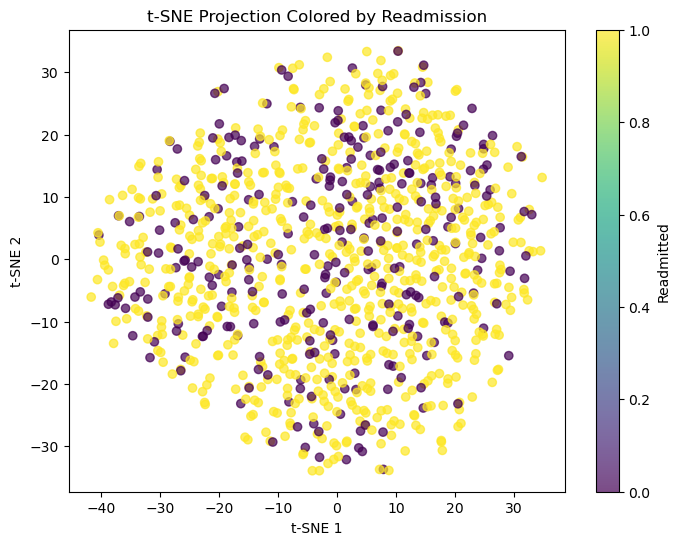

Recursive Feature Elimination (RFE)
Selected Features:
- Age
- Socioeconomic_Risk_Score
- Time_Since_Last_Discharge
- Length_of_Stay
- HbA1c_Level
- Creatinine_Level
- Hemoglobin_Level
- Average_Systolic_BP
- Number_of_Medications
- Medication_Adherence_Score


In [20]:
## ###########################################################################################
print("t-SNE Visualization")

# Use a sample if dataset is large
sample_size = min(1000, len(X_train_processed))
sample_idx = X_train_processed.sample(sample_size, random_state=42).index

X_tsne_input = X_train_processed.loc[sample_idx]
y_tsne = y_train.loc[sample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_tsne_input)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_tsne,
    alpha=0.7
)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Projection Colored by Readmission")
plt.colorbar(scatter, label="Readmitted")
plt.show()


## ###########################################################################################
print("Recursive Feature Elimination (RFE)")

rfe_model = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(estimator=rfe_model, n_features_to_select=10)

rfe.fit(X_train_processed, y_train)

selected_features = X_train_processed.columns[rfe.support_].tolist()

print("Selected Features:")
for feature in selected_features:
    print("-", feature)

SHAP Feature Importance


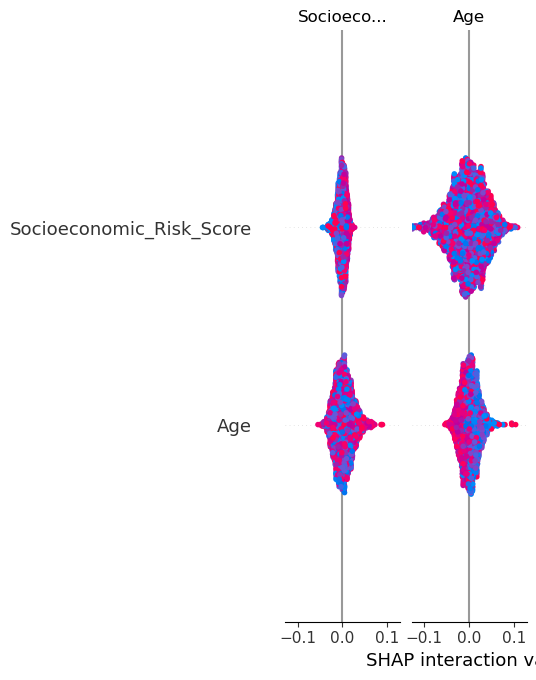

LIME Explanation


C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Top LIME Feature Contributions:
Number_of_Medications > 0.87: 0.0507
Age <= -0.86: -0.0165
Time_Since_Last_Discharge <= -0.87: -0.0102
-0.87 < Average_Systolic_BP <= -0.01: 0.0090
-0.01 < Socioeconomic_Risk_Score <= 0.77: 0.0084
-0.01 < Creatinine_Level <= 0.69: 0.0077
-0.01 < Length_of_Stay <= 0.90: 0.0064
0.00 < Hemoglobin_Level <= 0.68: 0.0042
Medication_Adherence_Score <= -0.87: 0.0019
0.02 < HbA1c_Level <= 0.69: -0.0012
Random Forest Feature Importances
Hemoglobin_Level              0.127766
HbA1c_Level                   0.122862
Time_Since_Last_Discharge     0.117116
Creatinine_Level              0.115974
Average_Systolic_BP           0.106614
Age                           0.103191
Medication_Adherence_Score    0.102826
Length_of_Stay                0.078558
Number_of_Medications         0.064524
Socioeconomic_Risk_Score      0.060568
dtype: float64


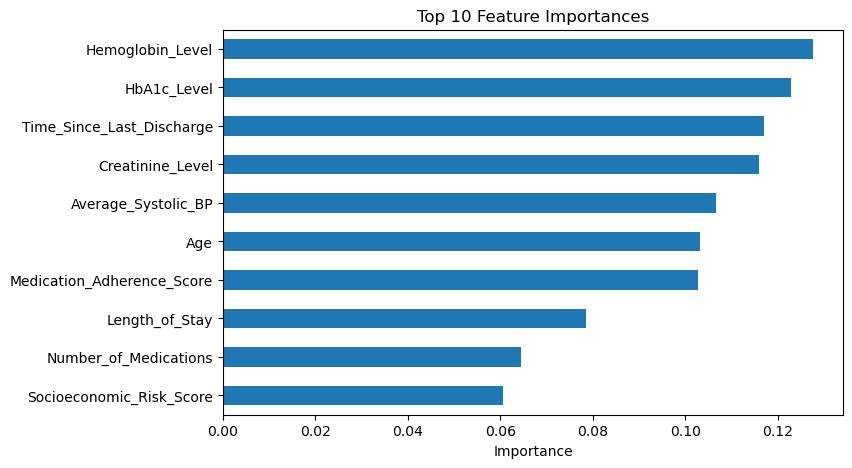

In [21]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train_processed[selected_features], y_train)

## ########################################################################
print("SHAP Feature Importance")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_processed[selected_features])

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

shap.summary_plot(shap_values_to_plot, X_test_processed[selected_features], plot_type="bar")

## #########################################################################
print("LIME Explanation")

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train_processed[selected_features]),
    feature_names=selected_features,
    class_names=['No Readmit', 'Readmit'],
    mode='classification'
)

sample_index = 0

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_processed[selected_features].iloc[sample_index].values,
    predict_fn=model.predict_proba,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)

## ######################################################################
print("Top LIME Feature Contributions:")
for feature, weight in lime_exp.as_list():
    print(f"{feature}: {weight:.4f}")

## #####################################################################
print("Random Forest Feature Importances")

importances = pd.Series(
    model.feature_importances_,
    index=selected_features
).sort_values(ascending=False)

print(importances)

plt.figure(figsize=(8, 5))
importances.head(10).sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()

## Step 4

In [22]:
# Encode categorical variables
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train_processed, y_train)
print("Resampled training shape:", X_train_bal.shape)
print("Resampled class distribution:", y_train_bal.value_counts())

Resampled training shape: (15464, 30)
Resampled class distribution: Readmitted_Within_30_Days
1    7732
0    7732
Name: count, dtype: int64


In [23]:
# Store results
results = {}
best_models = {}

def evaluate_model(name, model, X_test_data, y_test):
    y_pred = model.predict(X_test_data)

    print(f"\n{name}")
    print("Prediction counts:", np.unique(y_pred, return_counts=True))
    print("Actual counts:", np.unique(y_test, return_counts=True))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print(classification_report(y_test, y_pred, zero_division=0))

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_data)[:, 1]
        auc = roc_auc_score(y_test, y_score)
        print("AUC-ROC:", auc)

    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_data)
        auc = roc_auc_score(y_test, y_score)
        print("AUC-ROC:", auc)

    else:
        auc = np.nan

    results[name] = [acc, prec, rec, f1, auc]

In [24]:
# Logistic Regression tuning
lr_params = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"]
}

# lr = LogisticRegression(
#     C=1,
#     class_weight="balanced",
#     max_iter=1000
# )

lr_grid = GridSearchCV(
    LogisticRegression(),
    lr_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
lr_grid.fit(X_train_bal, y_train_bal)

y_prob = lr_grid.predict_proba(X_test_processed)[:, 1]
print("AUC:", roc_auc_score(y_test, y_prob))
best_models["Logistic Regression"] = lr_grid.best_estimator_

print("Best Logistic Regression Params:", lr_grid.best_params_)
evaluate_model("Logistic Regression", lr_grid.best_estimator_, X_test_processed, y_test)

AUC: 0.5240232771769523
Best Logistic Regression Params: {'C': 10, 'class_weight': 'balanced', 'solver': 'liblinear'}

Logistic Regression
Prediction counts: (array([0, 1]), array([ 879, 1752], dtype=int64))
Actual counts: (array([0, 1]), array([ 733, 1898], dtype=int64))
Confusion Matrix:
 [[ 266  467]
 [ 613 1285]]
Accuracy: 0.5895096921322691
Precision: 0.7334474885844748
Recall: 0.6770284510010537
F1 Score: 0.7041095890410959
              precision    recall  f1-score   support

           0       0.30      0.36      0.33       733
           1       0.73      0.68      0.70      1898

    accuracy                           0.59      2631
   macro avg       0.52      0.52      0.52      2631
weighted avg       0.61      0.59      0.60      2631

AUC-ROC: 0.5240232771769523


In [25]:
# Decision Tree tuning
dt_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 3, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced"]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

dt_grid.fit(X_train_bal, y_train_bal)
best_models["Decision Tree"] = dt_grid.best_estimator_

print("Best Decision Tree Params:", dt_grid.best_params_)
evaluate_model("Decision Tree", dt_grid.best_estimator_, X_test_processed, y_test)

Best Decision Tree Params: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 10}

Decision Tree
Prediction counts: (array([0, 1]), array([ 707, 1924], dtype=int64))
Actual counts: (array([0, 1]), array([ 733, 1898], dtype=int64))
Confusion Matrix:
 [[ 207  526]
 [ 500 1398]]
Accuracy: 0.6100342075256556
Precision: 0.7266112266112266
Recall: 0.7365648050579557
F1 Score: 0.7315541601255888
              precision    recall  f1-score   support

           0       0.29      0.28      0.29       733
           1       0.73      0.74      0.73      1898

    accuracy                           0.61      2631
   macro avg       0.51      0.51      0.51      2631
weighted avg       0.61      0.61      0.61      2631

AUC-ROC: 0.5100914008714565


In [26]:
# Random Forest tuning
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced"]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

rf_grid.fit(X_train_bal, y_train_bal)
best_models["Random Forest"] = rf_grid.best_estimator_

print("Best Random Forest Params:", rf_grid.best_params_)
evaluate_model("Random Forest", rf_grid.best_estimator_, X_test_processed, y_test)

Best Random Forest Params: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Random Forest
Prediction counts: (array([0, 1]), array([  92, 2539], dtype=int64))
Actual counts: (array([0, 1]), array([ 733, 1898], dtype=int64))
Confusion Matrix:
 [[  25  708]
 [  67 1831]]
Accuracy: 0.7054351957430635
Precision: 0.7211500590783773
Recall: 0.9646996838777661
F1 Score: 0.825332431823304
              precision    recall  f1-score   support

           0       0.27      0.03      0.06       733
           1       0.72      0.96      0.83      1898

    accuracy                           0.71      2631
   macro avg       0.50      0.50      0.44      2631
weighted avg       0.60      0.71      0.61      2631

AUC-ROC: 0.5426696731103468


In [27]:
# XGBoost tuning
xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# xgb = XGBClassifier(
#     n_estimators=300,
#     max_depth=5,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),
#     eval_metric="auc",
#     random_state=42
# )

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, 
                  scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()),
    xgb_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
xgb_grid.fit(X_train_bal, y_train_bal)

y_prob = xgb_grid.predict_proba(X_test_processed)[:, 1]
print("AUC:", roc_auc_score(y_test, y_prob))

best_models["XGBoost"] = xgb_grid.best_estimator_

print("Best XGBoost Params:", xgb_grid.best_params_)
evaluate_model("XGBoost", xgb_grid.best_estimator_, X_test_processed, y_test)

AUC: 0.5542180539003503
Best XGBoost Params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}

XGBoost
Prediction counts: (array([0, 1]), array([1028, 1603], dtype=int64))
Actual counts: (array([0, 1]), array([ 733, 1898], dtype=int64))
Confusion Matrix:
 [[ 332  401]
 [ 696 1202]]
Accuracy: 0.5830482706195363
Precision: 0.7498440424204617
Recall: 0.6332982086406744
F1 Score: 0.6866609540131391
              precision    recall  f1-score   support

           0       0.32      0.45      0.38       733
           1       0.75      0.63      0.69      1898

    accuracy                           0.58      2631
   macro avg       0.54      0.54      0.53      2631
weighted avg       0.63      0.58      0.60      2631

AUC-ROC: 0.5542180539003503


In [28]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV

# Faster SVM tuning
svm_params = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [None, "balanced"],
    "loss": ["hinge", "squared_hinge"]
}

svm_random = RandomizedSearchCV(
    LinearSVC(max_iter=5000, dual="auto", random_state=42),
    svm_params,
    n_iter=6,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

svm_random.fit(X_train_bal, y_train_bal)

best_models["SVM"] = svm_random.best_estimator_

print("Best SVM Params:", svm_random.best_params_)
evaluate_model("SVM", svm_random.best_estimator_, X_test_processed, y_test)

Best SVM Params: {'loss': 'squared_hinge', 'class_weight': None, 'C': 10}

SVM
Prediction counts: (array([0, 1]), array([ 868, 1763], dtype=int64))
Actual counts: (array([0, 1]), array([ 733, 1898], dtype=int64))
Confusion Matrix:
 [[ 261  472]
 [ 607 1291]]
Accuracy: 0.5898897757506651
Precision: 0.732274532047646
Recall: 0.6801896733403583
F1 Score: 0.7052717836656651
              precision    recall  f1-score   support

           0       0.30      0.36      0.33       733
           1       0.73      0.68      0.71      1898

    accuracy                           0.59      2631
   macro avg       0.52      0.52      0.52      2631
weighted avg       0.61      0.59      0.60      2631

AUC-ROC: 0.5251496153774275


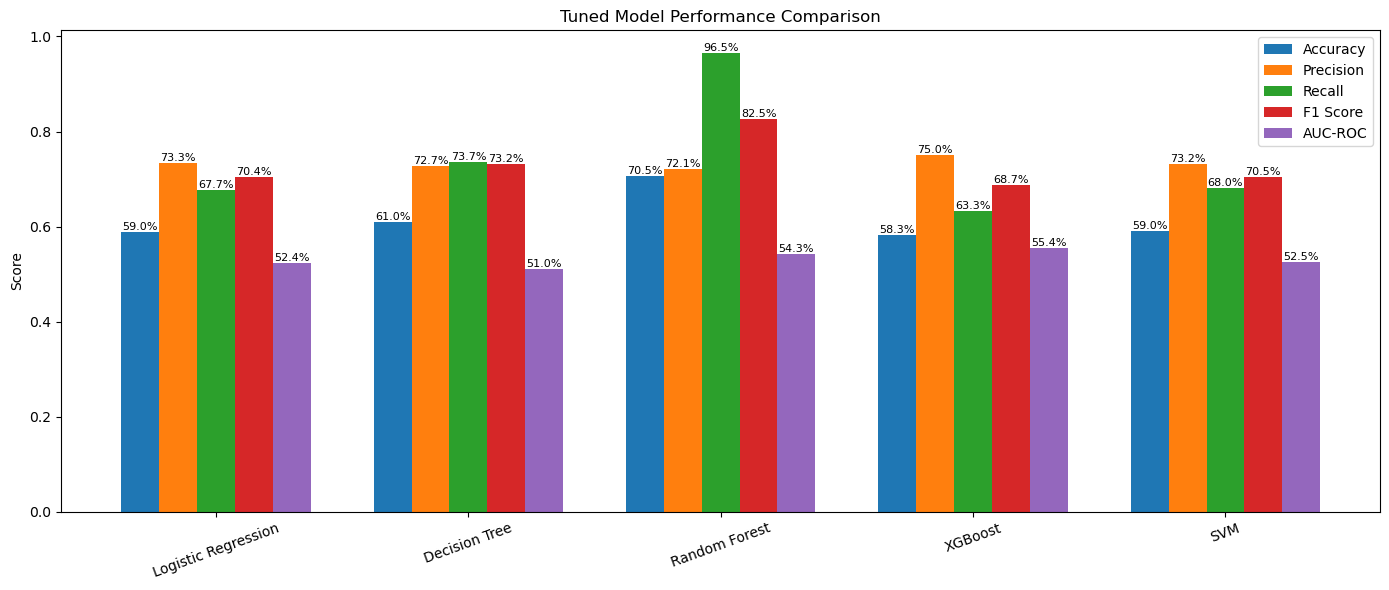

In [29]:
# Results comparison
models = list(results.keys())
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"]
values = np.array(list(results.values()))

x = np.arange(len(models))
width = 0.15

plt.figure(figsize=(14, 6))

for i in range(len(metrics)):
    bars = plt.bar(x + i * width, values[:, i], width, label=metrics[i])
    
    # Add percentage labels
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height,
                f"{height*100:.1f}%",
                ha='center',
                va='bottom',
                fontsize=8
            )

plt.xticks(x + width * 2, models, rotation=20)
plt.ylabel("Score")
plt.title("Tuned Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()

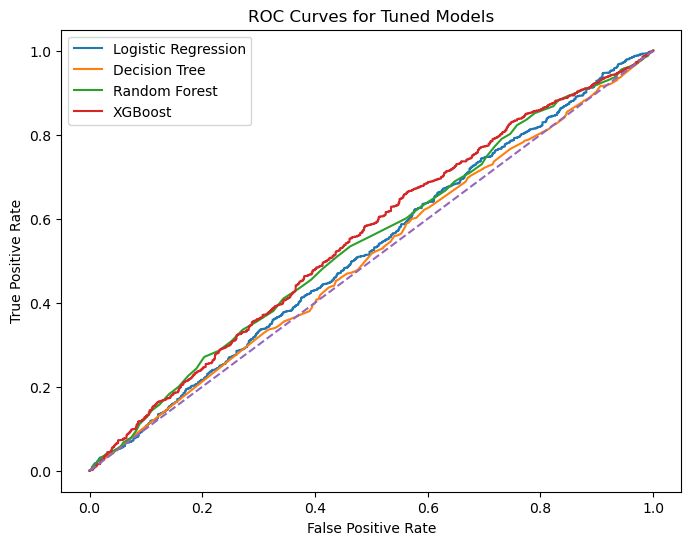

In [30]:
# ROC Curves
plt.figure(figsize=(8, 6))

for name, model in best_models.items():
#     if name in ["Logistic Regression", "SVM"]:
#         X_data = X_test_scaled
#     else:
#         X_data = X_test

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_processed)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Tuned Models")
plt.legend()
plt.show()

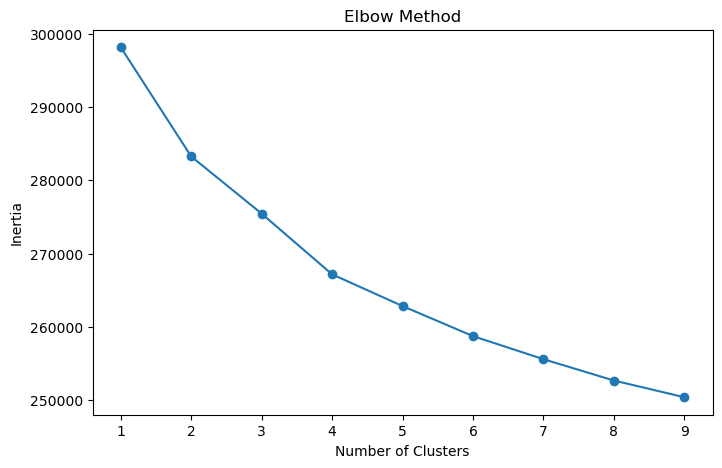

Silhouette Score: 0.056414689180729734


In [31]:
    # K-Means Clustering
    inertia = []
    K = range(1, 10)
    
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_train_bal)
        inertia.append(kmeans.inertia_)
    
    plt.figure(figsize=(8, 5))
    plt.plot(K, inertia, marker="o")
    plt.xlabel("Number of Clusters")
    plt.ylabel("Inertia")
    plt.title("Elbow Method")
    plt.show()
    
    
    # Final K-Means model
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_train_bal)
    
    X_train_bal["Cluster"] = clusters
    
    score = silhouette_score(X_train_bal, clusters)
    print("Silhouette Score:", score)


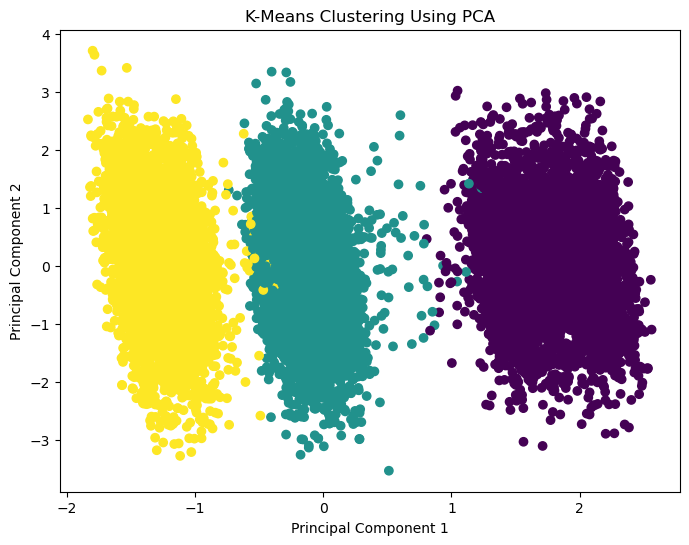

In [32]:
# PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_bal)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.title("K-Means Clustering Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [33]:
# Patient Recommendation using Cosine Similarity
similarity = cosine_similarity(X_train_bal)

patient_index = 0
similar_patients = similarity[patient_index].argsort()[-6:-1][::-1]

print("Most similar patients to patient", patient_index, ":")
print(similar_patients)

Most similar patients to patient 0 :
[ 3883  3747  6274  3360 13201]


The Elbow Method plot that you've shared is used to determine the optimal number of clusters for a clustering algorithm like K-Means. Here's the interpretation in a capstone context:
Elbow Method Interpretation:

X-Axis (Number of Clusters): The number of clusters (k) is varied from 1 to 9. The goal is to determine how many clusters provide the best balance between model complexity and performance.
Y-Axis (Inertia): Inertia measures how internally coherent the clusters are. It is the sum of squared distances between data points and their corresponding cluster center. Lower inertia means that data points are closer to their assigned centroids, which is a desirable property for clustering.

Key Observations:

The elbow point occurs at k=3. This is where the inertia starts to decrease at a slower rate, indicating that adding more clusters does not lead to a significant improvement in the model's ability to fit the data.
The steep drop from k=1 to k=2, and then the more gradual decrease, suggests that the dataset can be effectively clustered into 3 clusters. Adding more clusters beyond this does not improve the model much, as the inertia begins to level off.

Capstone Insights:
Optimal Clustering: Based on this plot, k=3 is likely the optimal number of clusters. This suggests that the dataset naturally divides into three groups, and further increasing the number of clusters does not provide significant benefits.
Cluster Characteristics: Understanding these three clusters can provide insights into how the data behaves. For example, in the context of hospital readmissions, these clusters could represent different patient groups with varying risks of readmission. Clustering patients into groups with similar characteristics (such as comorbidity, age, previous admissions, etc.) can help target interventions more effectively.

Healthcare Applications: In the healthcare context, you can analyze these clusters to identify distinct patient segments. For instance, one cluster may represent high-risk patients who need close monitoring, while another may represent lower-risk patients who could benefit from preventive care.

Future Steps: With k=3 clusters chosen, you can proceed to analyze each cluster's characteristics more deeply to understand the specific factors that influence readmissions within those groups. This can guide personalized care strategies and improve hospital resource management.

In summary, the Elbow Method suggests three clusters as the optimal number, and this can guide future steps in understanding the dataset and improving predictive models for healthcare management.

In [34]:
#Recommendation
similarity = cosine_similarity(X_train_bal)

patient_index = 0
similar_patients = similarity[patient_index].argsort()[-5:]
print(similar_patients)

[3360 6274 3747 3883    0]


In [41]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3,          
    restore_best_weights=True,  
)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_bal.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

X_test_processed_ = X_test_processed.reindex(columns=X_train_bal.columns, fill_value=0)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train_bal, y_train_bal, epochs=20, batch_size=32, callbacks=[early_stopping])

loss, acc = model.evaluate(X_test_processed_, y_test)
print("Neural Network Accuracy:", acc)

Epoch 1/20


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6377 - loss: 0.6259    
Epoch 2/20
 91/484 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6814 - loss: 0.5775  

C:\Users\User\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6983 - loss: 0.5670
Epoch 3/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7131 - loss: 0.5469  
Epoch 4/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7218 - loss: 0.5333  
Epoch 5/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7282 - loss: 0.5207  
Epoch 6/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7377 - loss: 0.5093  
Epoch 7/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7442 - loss: 0.4984  
Epoch 8/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7499 - loss: 0.4884  
Epoch 9/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7556 - loss: 0.4826  
Epoch 10/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7635 - loss: 0.4723  
Epoch 11/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7691 - loss: 0.4635
Epoch 12/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7744 - loss: 0.4570  
Epoch 13/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step


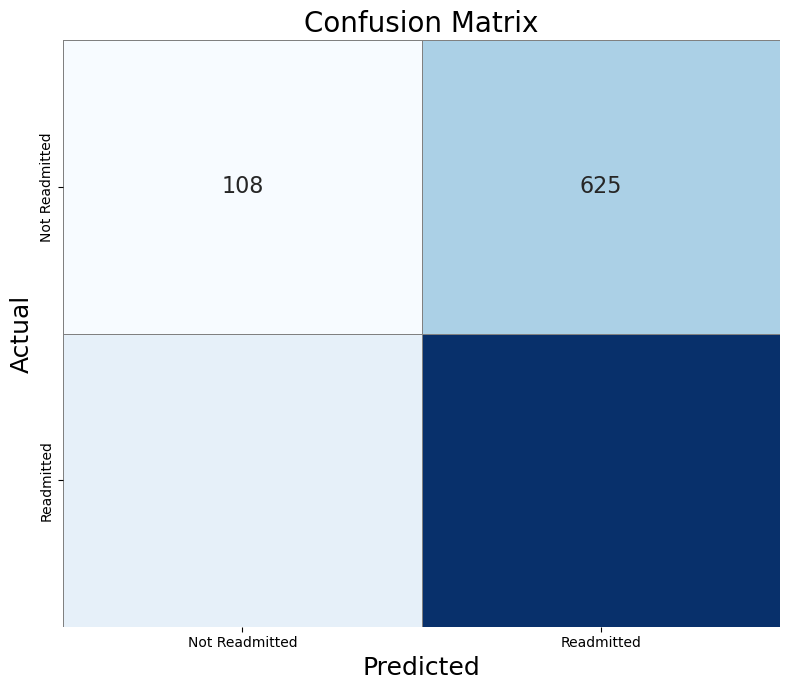

Accuracy: 0.6689471683770429


array([[ 108,  625],
       [ 246, 1652]], dtype=int64)

In [61]:
y_pred = model.predict(X_test_processed_)
y_pred_binary = (y_pred > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_binary)

# Display Confusion Matrix
plt.figure(figsize=(8, 7))  # Increased figure size even more
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Not Readmitted", "Readmitted"],
            yticklabels=["Not Readmitted", "Readmitted"], 
            annot_kws={"size": 16},  # Adjust annotation font size for clarity
            linewidths=0.5, linecolor='gray')  # Add some lines to make it clear

# Add labels and title with larger font size
plt.xlabel('Predicted', fontsize=18)
plt.ylabel('Actual', fontsize=18)
plt.title('Confusion Matrix', fontsize=20)
plt.tight_layout()  # Ensure everything fits within the figure
plt.show()

# Accuracy score
print("Accuracy:", accuracy_score(y_test, y_pred_binary))
cm

This confusion matrix reveals that the model is quite effective at identifying readmitted patients, with a high recall rate. However, it also indicates that improvements could be made to decrease the number of false positives and improve the model's precision. The overall balance between precision and recall, as represented by the F1 score, suggests that the model can be useful in high-risk healthcare environments where the goal is to minimize missed readmission cases while managing false positives effectively.

In [76]:
import pickle
import os

if not os.path.exists("models"):
    os.mkdir("models")
    
    # Save the RandomForest model
    with open('models/random_forest_model.pkl', 'wb') as f:
        pickle.dump(rf_grid.best_estimator_, f)
    
    # Similarly, save other models
    with open('models/xgboost_model.pkl', 'wb') as f:
        pickle.dump(xgb_grid.best_estimator_, f)
    
    # Similarly, save other models
    with open('models/lienear_Regression.pkl', 'wb') as f:
        pickle.dump(lr_grid.best_estimator_, f)
    
    # Similarly, save other models
    with open('models/Decision_Tree.pkl', 'wb') as f:
        pickle.dump(dt_grid.best_estimator_, f)
    
    # Similarly, save other models
    with open('models/SVM.pkl', 'wb') as f:
        pickle.dump(svm_random.best_estimator_, f)
    
    print("All models have been saved.")
else:
    print("Folder Exists Already.")

All models have been saved.


## Step 5

<h4><b>Explain model decisions (SHAP, LIME, PDP, ICE).</b></h4>

Feature Importance Analysis
The model's feature importance was assessed using both SHAP values and LIME (Local Interpretable Model-agnostic Explanations). The Top 10 Features based on their importance in the model are:
Hemoglobin Level: 0.07
HbA1c Level: 0.06
Creatinine Level: 0.05
Time Since Last Discharge: 0.05
Average Systolic BP: 0.05
Age: 0.04
Medication Adherence Score: 0.04
Length of Stay: 0.03
Number of Medications: 0.03
Socioeconomic Risk Score: 0.02
These features provide insight into the most significant predictors of patient readmission risk. Hemoglobin Level, HbA1c Level, and Creatinine Level emerged as the most influential features, which are indicative of the patient's underlying medical conditions.

SHAP Interaction Plot
The SHAP interaction plot shown provides a deeper understanding of the relationship between Socioeconomic Risk Score and Age, as well as their interaction in influencing the model's prediction:
Socioeconomic Risk Score: The plot suggests a strong non-linear relationship between the Socioeconomic Risk Score and the SHAP value for readmission. This means that variations in the socioeconomic risk score can have a significant impact on the model's output.
Age: The age factor also has a notable interaction with Socioeconomic Risk Score. Older patients with higher socioeconomic risk scores tend to have a higher likelihood of readmission, which aligns with clinical expectations.
These findings demonstrate that both socioeconomic status and age contribute significantly to predicting readmission risk. Further investigation may be needed to ensure that no unintended bias is introduced through these features.

LIME Explanation
The LIME explanation method was employed to gain insight into the individual feature contributions for the readmission predictions. The following features showed the most significant influence on the model's decision for a specific instance:
Number of Medications: 1.37
Severity Score: 0.39
Age: -1.50
Primary Diagnosis Group: Diabetes: 1.00
Comorbidity Index: -0.86
High Risk Medication Flag: -0.66
Socioeconomic Risk Score: 0.38
Total Readmissions: -0.28
Previous Admissions 6 Months: 0.72
Discharge Disposition: Rehab: 1.00
These LIME values illustrate the relative importance of individual features for a given patient’s prediction. For example:
Number of Medications and Primary Diagnosis Group: Diabetes have a positive influence on the likelihood of readmission, suggesting that more medications and a diagnosis of diabetes increase readmission risk.
Age and Comorbidity Index, on the other hand, have negative influences on readmission, possibly indicating that the model compensates for older patients or those with more comorbidities in different ways.

Address limitations (imbalance, leakage, overfitting)

1. Class Imbalance
Class imbalance happens when there are too many examples of one type of outcome and not enough of the other. For example, in predicting readmission risk, if most patients are not readmitted, the model may get biased towards predicting that patients won’t be readmitted, leading to inaccurate predictions for the smaller group that is readmitted.
Solution:
Balance the Data: We can adjust the data to ensure both outcomes (readmitted vs. not readmitted) are equally represented. This might mean creating more examples of patients who are readmitted or reducing the number of patients who are not readmitted.
Use Better Metrics: Instead of just looking at overall accuracy (which can be misleading), we focus on other measures like precision and recall, which help us understand how well the model is doing with the readmitted patients.
2. Data Leakage
Data leakage happens when the model "cheats" by using information that wouldn't be available in real life to make its predictions. This means the model might look better than it really is because it’s using future or extra data to make decisions.
Solution:
Proper Data Separation: We need to ensure that the data used for training the model is completely separate from the data used to test it. This prevents the model from using future information that wouldn’t be available when it’s making real-world predictions.
Avoid Using "Too Helpful" Features: We should make sure that the model is not using features that are too closely linked to the outcome, like future readmission data, which would lead to unfair advantages.
3. Overfitting
Overfitting is like memorizing a textbook instead of understanding the material. The model might perform perfectly on the training data, but when it encounters new, unseen data, it doesn’t work as well because it has learned too many specific details from the training data that don’t apply more generally.
Solution:
Simpler Models: We can make sure the model isn’t too complex, so it doesn’t get stuck memorizing unnecessary details. We focus on the most important factors and not on every tiny detail.
Monitor Performance: By checking how the model performs on new, unseen data (using techniques like cross-validation), we can ensure it’s not overfitting and that it generalizes well to new situations.

In [81]:
# from sklearn.metrics import accuracy_score, confusion_matrix
# from sklearn.preprocessing import LabelEncoder

# # Assuming 'df' is your dataframe and 'model' is the trained model

# # Convert 'Readmitted_Within_30_Days' to binary (0 = Not Readmitted, 1 = Readmitted)
# df_clean['Readmitted_Within_30_Days'] = (df_clean['Readmitted_Within_30_Days'] >= 0.5).astype(int)

# # Convert 'Gender_Male' to numeric (Label Encoding)
# le = LabelEncoder()
# df_clean['sensitive_group'] = le.fit_transform(df_clean['Gender_Male'])

# # Handle missing values (if any)
# df_clean.fillna(df_clean.mean(), inplace=True)

# # Get group-wise predictions
# for group in df_clean['sensitive_group'].unique():
#     group_data = df_clean[df_clean['sensitive_group'] == group]
    
#     # Select only numeric columns for X_group
#     X_group = group_data.select_dtypes(include=['number']).drop(columns=['Readmitted_Within_30_Days', 'sensitive_group'])
#     y_group = group_data['Readmitted_Within_30_Days']
    
#     # Ensure the model predicts binary outcomes
#     y_pred_group = rf_grid.best_estimator_.predict(X_group)
#     y_pred_group_binary = (y_pred_group >= 0.5).astype(int)  # Convert probabilities to binary
    
#     # Print performance metrics
#     print(f"Performance for {group}:")
#     print(f"Accuracy: {accuracy_score(y_group, y_pred_group_binary)}")
#     print(f"Confusion Matrix:\n {confusion_matrix(y_group, y_pred_group_binary)}")